# Lab 5: PCA on T20 International Dataset
**Author:** Vandan Amin  
This notebook applies Principal Component Analysis (PCA) to a T20 cricket dataset. We explore correlations between numeric features, perform eigen-analysis, and visualize data projections to understand patterns in performance metrics.


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from numpy.linalg import eig

# Set global font style (Times New Roman must be installed on your system)
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 14

# Load dataset
df = pd.read_csv("T20 International Dataset.csv")

# Select relevant numeric features
features = ['AverageScore', 'delivery_left', 'score', 'CurrentRunRate',
            'wicketsLeft', 'Run_In_Last5', 'Final_Score']
X = df[features].dropna()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## Covariance Matrix Heatmap
We begin by computing the covariance matrix of the standardized features to observe relationships between variables.


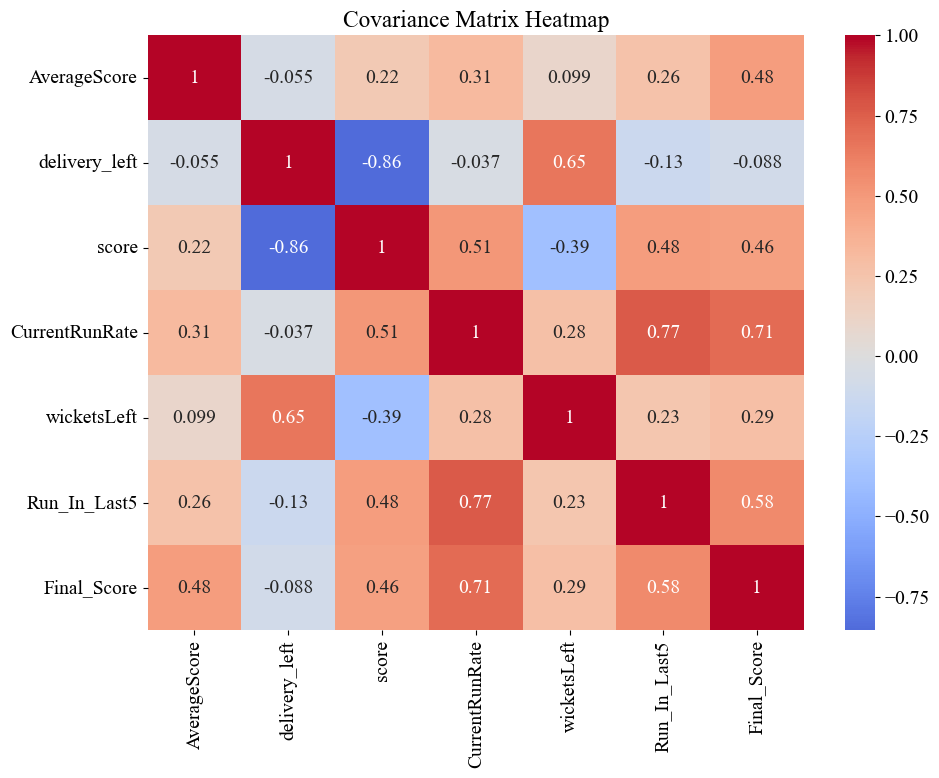

In [8]:
# Compute covariance matrix
cov_matrix = np.cov(X_scaled.T)

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cov_matrix, annot=True, xticklabels=features, yticklabels=features, cmap='coolwarm', center=0)
plt.title("Covariance Matrix Heatmap")
plt.tight_layout()
plt.savefig("Lab5_VandanAmin_CovarianceHeatmap.png", dpi=300)
plt.show()


This heatmap shows the covariance between numerical features after standardization. Strong positive and negative values indicate which features move together or in opposite directions. For example, `score` and `Final_Score` are strongly positively correlated, which aligns with cricket game logic. This matrix helps us understand which variables contribute similarly to variance in the dataset.


## Eigenvalues and Eigenvectors
We perform eigen decomposition on the covariance matrix. The eigenvalues tell us how much variance each principal component explains. The eigenvectors show the direction of these components in the original feature space.


In [13]:
# Eigen decomposition
eigenvalues, eigenvectors = eig(cov_matrix)

# Sort in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]


### Bar Chart of Eigenvalues
The eigenvalue plot below shows the variance captured by each principal component. Larger values represent more informative components.


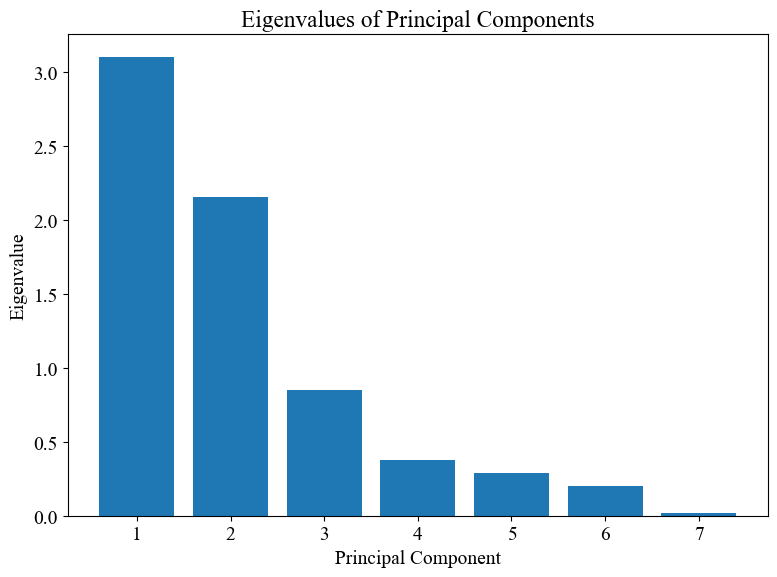

In [39]:
plt.figure(figsize=(8, 6))
plt.bar(range(1, len(eigenvalues)+1), eigenvalues)
plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalues of Principal Components")
plt.tight_layout()
plt.savefig("Lab5_VandanAmin_EigenvaluesBarChart.png", dpi=300)
plt.show()


The bar chart displays the magnitude of each eigenvalue, indicating the variance explained by each principal component. The first component has the highest eigenvalue, meaning it captures the largest portion of total variance. This helps justify how many components to keep in further visualizations.


### Eigenvectors Heatmap
This heatmap shows how each original feature contributes to each principal component.


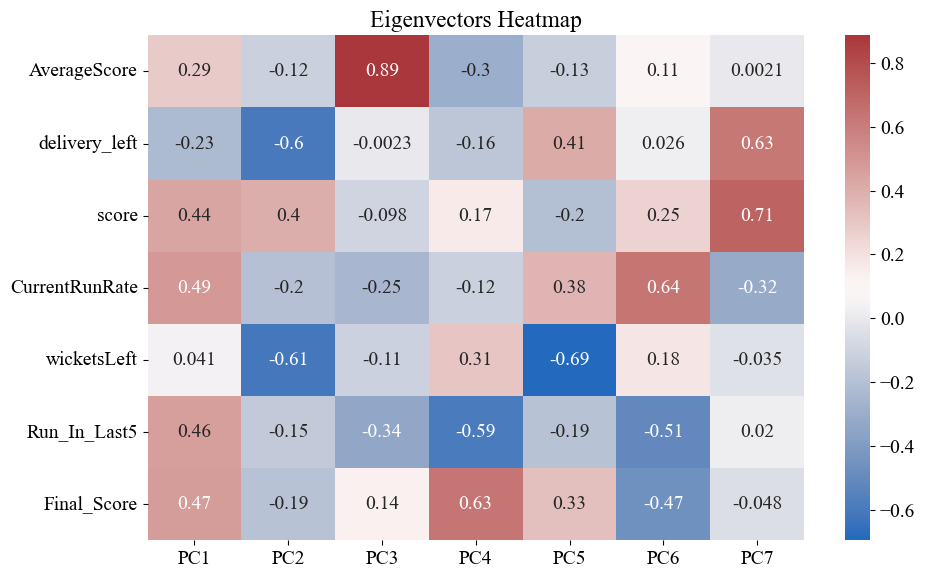

In [20]:
plt.figure(figsize=(10, 6))
sns.heatmap(eigenvectors, annot=True, cmap='vlag',
            xticklabels=[f'PC{i+1}' for i in range(len(eigenvalues))],
            yticklabels=features)
plt.title("Eigenvectors Heatmap")
plt.tight_layout()
plt.savefig("Lab5_VandanAmin_EigenvectorsHeatmap.png", dpi=300)
plt.show()


The heatmap visualizes how each feature contributes to each principal component. Large positive or negative values indicate strong influence. For example, `Final_Score` and `score` both strongly influence PC1, suggesting this component captures overall team performance.


## Scree Plot - Cumulative Variance Explained
The Scree Plot helps determine how many principal components are needed to retain most of the variance. A sharp elbow in the plot indicates a natural cut-off.


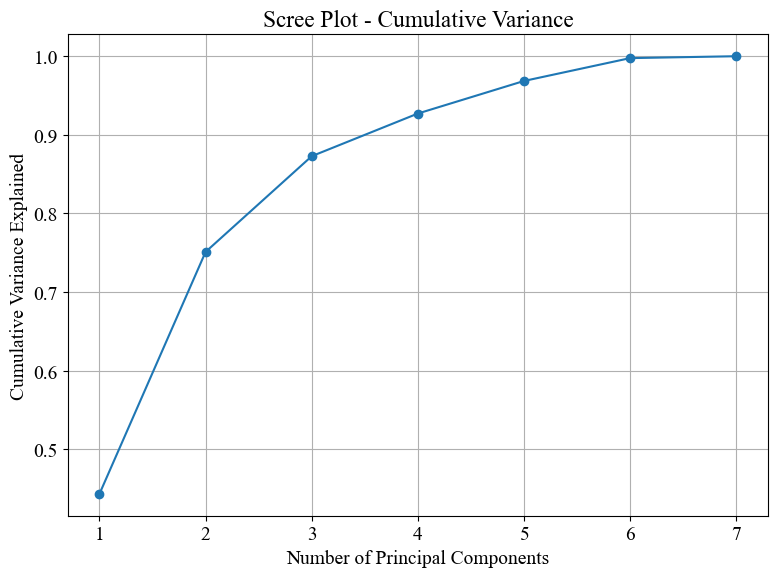

In [23]:
from sklearn.decomposition import PCA

# Fit PCA on the standardized dataset
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Calculate cumulative variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Scree Plot
plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("Scree Plot - Cumulative Variance")
plt.grid(True)
plt.tight_layout()
plt.savefig("Lab5_VandanAmin_ScreePlot.png", dpi=300)
plt.show()


The scree plot shows cumulative variance explained by each added principal component. The curve flattens after PC3 or PC4, suggesting that most of the useful variance is captured by the first few components. This helps determine an optimal number of components to retain.


## 2D PCA Scatter Plot
This scatter plot shows the projection of the data onto the first two principal components. This helps reveal natural clusters or spread in the dataset using the most informative directions.


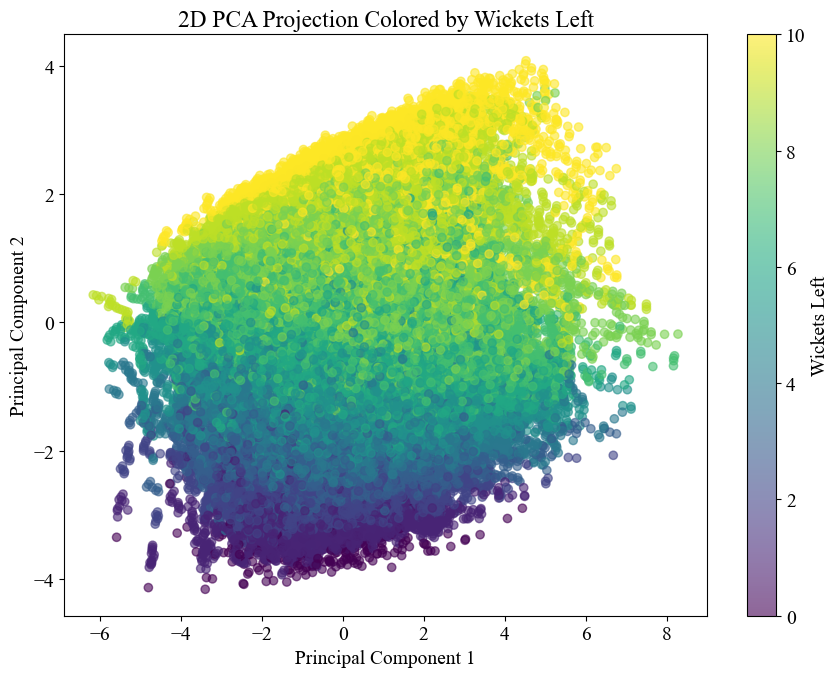

In [28]:
# Color points by 'wicketsLeft'
plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df.loc[X.index, 'wicketsLeft'], cmap='viridis', alpha=0.6)
cbar = plt.colorbar(scatter)
cbar.set_label('Wickets Left')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Projection Colored by Wickets Left")
plt.tight_layout()
plt.savefig("Lab5_VandanAmin_2DPCA_WicketsLeft.png", dpi=300)
plt.show()


This scatter plot projects the data onto the first two principal components. Initially, the pattern was hard to interpret due to overlapping points. Adding color based on `wicketsLeft` revealed trends: higher or lower wicket counts tend to group in certain PCA regions, reflecting underlying match progress dynamics.


## Biplot with Feature Vectors
This biplot overlays the original feature directions on the 2D PCA projection. It helps interpret how much each feature contributes to the principal components, and in which direction the influence lies.


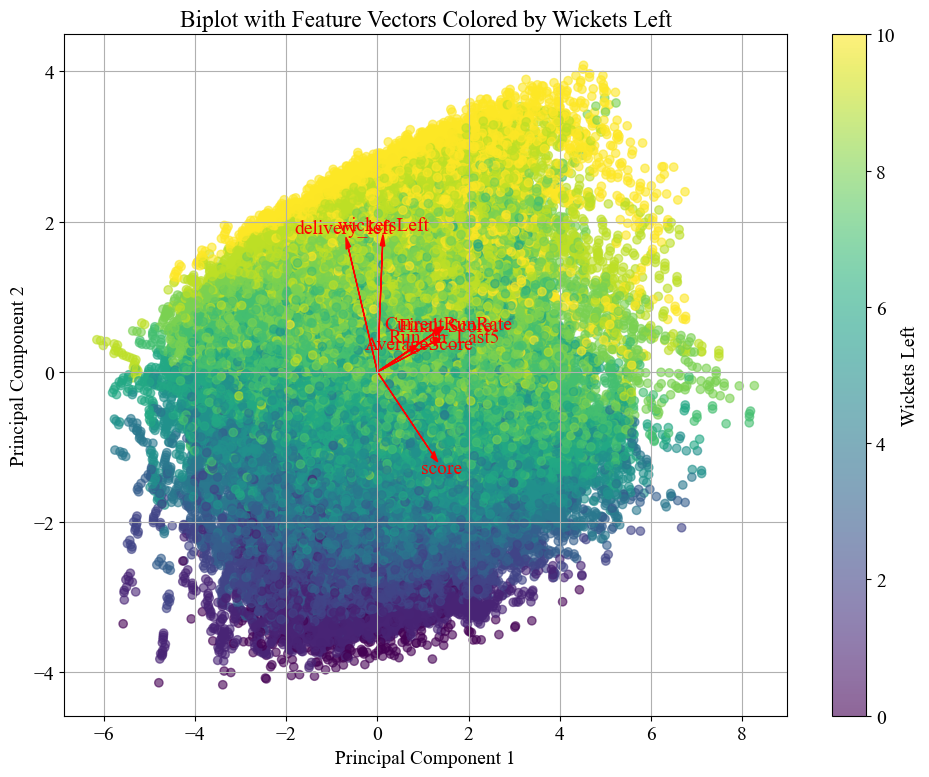

In [31]:
# Biplot: PCA scatter with feature vector arrows
plt.figure(figsize=(10, 8))

# Scatter plot colored by 'wicketsLeft'
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df.loc[X.index, 'wicketsLeft'], cmap='viridis', alpha=0.6)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Biplot with Feature Vectors Colored by Wickets Left")

# Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Wickets Left')

# Feature vectors
for i, feature in enumerate(features):
    plt.arrow(0, 0, pca.components_[0, i]*3, pca.components_[1, i]*3,
              color='red', head_width=0.1, length_includes_head=True)
    plt.text(pca.components_[0, i]*3.2, pca.components_[1, i]*3.2,
             feature, color='red', ha='center', va='center')

plt.grid(True)
plt.tight_layout()
plt.savefig("Lab5_VandanAmin_Biplot.png", dpi=300)
plt.show()


This biplot overlays feature vectors on the 2D PCA scatter plot. Arrows represent the original features' contribution and direction within the new PCA space. For example, `Final_Score` points strongly along PC1, confirming that PC1 captures scoring ability. The vector angles also help interpret feature correlation visually.


## 2D PCA Projection (PC1 vs PC3)
This plot shows the projection of the data onto Principal Components 1 and 3. Color is mapped to the number of wickets left, which helps explore underlying relationships between match progress and performance structure.


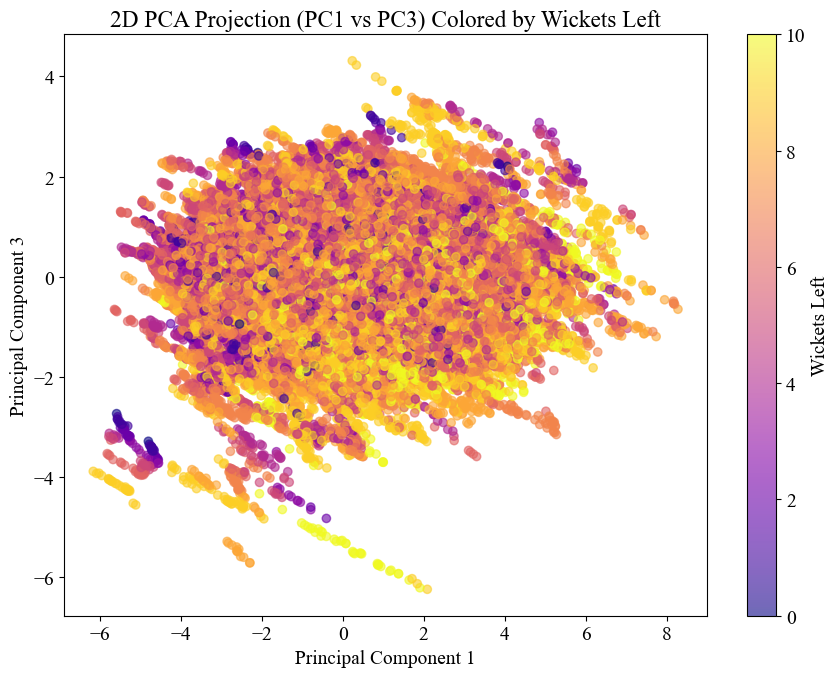

In [34]:
# 2D PCA Projection using PC1 vs PC3 colored by 'wicketsLeft'
plt.figure(figsize=(9, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 2], c=df.loc[X.index, 'wicketsLeft'], cmap='plasma', alpha=0.6)
cbar = plt.colorbar(scatter)
cbar.set_label('Wickets Left')
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 3")
plt.title("2D PCA Projection (PC1 vs PC3) Colored by Wickets Left")
plt.tight_layout()
plt.savefig("Lab5_VandanAmin_2DPCA_PC1vsPC3.png", dpi=300)
plt.show()

This 2D plot visualizes PC1 vs PC3 and colors the data by `wicketsLeft`. While PC3 explains less variance than PC2, this view still uncovers distinct groupings based on match progress. It reinforces earlier patterns and offers an alternate projection for exploring structure in the data.


## Final Summary
Through this lab, I applied Principal Component Analysis (PCA) to a real-world T20 cricket dataset. By exploring covariance, eigenvalues, and projections onto principal components, I identified key patterns in team performance metrics. Visualizations like the scree plot, biplot, and colored 2D scatter plots revealed underlying structure in how features like score, run rate, and wickets interact.
